## Denoising Diffusion Probablistic Models (DDPM)
The whole idea
1. Taking a clean image, adding noise gradually (forward process)
2. Training a U-Net (as per theoritical explanation) to predict "what noise was added??" given (noisy image, timestep)
3. To generate: starting from pure noise, asking U-Net to predict noise, subtracting it, repeating

**Loss = MSE(predicted_noise, actual_noise)**  <- final form after reduction

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from tqdm.auto import tqdm
import math, os

os.makedirs('results/ddpm', exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [30]:
@dataclass
class DDPMConfig:
    timesteps: int = 1000       # T: number of noise/timestep steps (1000 per paper)
    beta_start: float = 1e-4    # noise at step 0 (almost none)
    beta_end: float = 0.02      # noise at step T (lots)
    in_channels: int = 3        # RGB images
    base_channels: int = 32     # U-Net width, small for CPU T0T
    epochs: int = 100            # would be great to see the loss go down  
    seed: int = 42              # Same as VAE for the comprehensive comparison
    # Impirically doing these following
    time_emb_dim: int = 128     # how to tell the network "which timestep is this?" -> often 4*base_channels
    lr: float = 1e-4            # lower than VAE — U-Net is sensitive
    batch_size: int = 64        # smaller than VAE since U-Net uses more memory
    

In [31]:
# Same as VAE
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

target_classes = {0: 0, 5: 1, 8: 2}
CLASSES = ('plane', 'dog', 'ship')

def filter_dataset(dataset, max_samples=None):
    indices = [i for i, target in enumerate(dataset.targets) if target in target_classes]
    if max_samples:
        indices = indices[:max_samples]
    dataset.data = dataset.data[indices]
    dataset.targets = [target_classes[dataset.targets[i]] for i in indices]
    return dataset
# 10_000 samples for training and 2000 for testing like in the VAE
train_dataset = filter_dataset(train_dataset, max_samples=10000)
test_dataset  = filter_dataset(test_dataset,  max_samples=2000)

config = DDPMConfig()
torch.manual_seed(config.seed)
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=config.batch_size, shuffle=False, num_workers=0)

Files already downloaded and verified
Files already downloaded and verified


# Noise Schedule

- This is NOT a neural network. It's a precomputed table that answers:
"During the forward path, at timestep t, how much of the original image is left vs how much is noise?"

- β_t (the variance of noise we want to predict at timestep t) goes from small (β_start=0.0001) to large (β_end=0.02) <br>
α_t = 1 - β_t (alpha is the original signal kept, where the summation of the noise ratio and image ratio is equal to ONE)<br>
ᾱ_t = α_1 × α_2 × ... × α_t  (cumulative product, the amount of the original image left at timestep t)
 
- The 'nice' formula**:  x_t = √ᾱ_t · x_0  +  √(1-ᾱ_t) · ε
to be able to jump DIRECTLY to any noise level without iterating.
<br><br>
'**': naming per HF blog

In [32]:

class NoiseSchedule:
    def __init__(self, cfg: DDPMConfig):
        self.T = cfg.timesteps
        # This is the core of the class -> scheduling β to go from 0.0001 to 0.02 over T steps
        # There's another option of using cosine beta scheduling, try later https://arxiv.org/abs/2102.09672
        self.betas = torch.linspace(cfg.beta_start, cfg.beta_end, cfg.timesteps)
        self.alphas = 1.0 - self.betas
        # Cumulative product: ᾱ_t
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

        # Pre-computiing -> used in add_noise() and sample()
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_alphas = torch.sqrt(self.alphas)

    def add_noise(self, x_0, t, noise):
        """
        Forward process shortcut: go directly from clean image to noisy image at step t.
        """
        # .view(-1,1,1,1) reshapes for broadcasting over (C,H,W) dimensions
        a = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1).to(x_0.device)
        b = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1).to(x_0.device)
        return a * x_0 + b * noise

schedule = NoiseSchedule(config)


# Visualizing the forward process
the gradual addition of noise

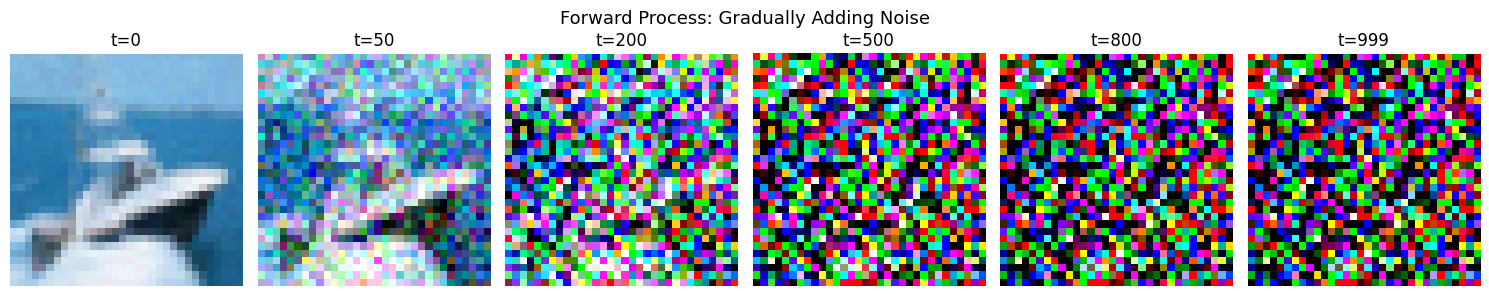

In [33]:
sample_img = train_dataset[0][0].unsqueeze(0)  # shape: (1, 3, 32, 32)
noise = torch.randn_like(sample_img)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, t_val in enumerate([0, 50, 200, 500, 800, 999]):
    t = torch.tensor([t_val])
    noisy = schedule.add_noise(sample_img, t, noise)
    axes[i].imshow(noisy[0].clamp(0,1).permute(1,2,0))
    axes[i].set_title(f't={t_val}'); axes[i].axis('off')
plt.suptitle('Forward Process: Gradually Adding Noise', fontsize=13)
plt.tight_layout(); plt.savefig('results/ddpm/forward_process.png', dpi=150); plt.show()

# Training a U-Net model to Predict NOISE
- Why unet? 1st->bottleneck compression as in AE, 2nd->skip connection, gradient/information flow between encoder and decoder
- Why timestep t -> it's used to get the amount of noise/ the amount of noise differs from t to t

In [34]:
# Interesting to know we need it and how to encode it from the integer value t
class SinusoidalTimeEmbedding(nn.Module):
    """
    Converts timestep integer → high-dimensional vector (length = time_emb_dim)
    Same idea as positional encoding in Transformers OoO
    Why not just pass t as a number? Neural networks learn better
    from high-dimensional representations than single scalars!!!
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    # Also from HG blog!! simply, it's a sinosoidal function with different frequencies 
    # But why sin and cos? AI answers:"Sin and cos have nice properties that help the model learn better, such as being periodic and having a wide range of frequencies. They also allow the model to extrapolate to unseen timesteps, since the embeddings are based on a continuous function rather than discrete learned vectors.""
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=-1)

class ConvBlock(nn.Module):
    """Two convolutions + time embedding injection + residual connection"""
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch) # GroupNorm is a normalization technique that divides channels into groups and normalizes within each group. It's often used in diffusion models instead of BatchNorm because it works better with small batch sizes.
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()  # smooth ReLU variant, standard in diffusion
        self.time_proj = nn.Linear(time_dim, out_ch)  # project time → channel dim
        self.residual = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        # Add time info => WHICH timestep this is!!!
        h = h + self.time_proj(self.act(t_emb)).unsqueeze(-1).unsqueeze(-1)
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.residual(x)  # residual connection


In [35]:

class SimpleUNet(nn.Module):
    """
    Minimal U-Net for 32x32 images.

    Structure:
      Encoder:  32x32 → (pool) → 16x16 → (pool) → 8x8
      Bottleneck: 8x8
      Decoder:  8x8 → (upsample) → 16x16 → (upsample) → 32x32

    Skip connections: encoder features are concatenated with decoder features
    at matching resolutions (that's why decoder channels have *2).
    """
    def __init__(self, cfg: DDPMConfig):
        super().__init__()
        C = cfg.base_channels
        T = cfg.time_emb_dim

        # Time embedding: integer → vector
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(T),
            nn.Linear(T, T), nn.SiLU(),
        )

        # Encoder (downsampling)
        self.down1 = ConvBlock(cfg.in_channels, C, T)      # 32×32 → 32×32
        self.down2 = ConvBlock(C, C * 2, T)                 # 16×16 → 16×16
        self.pool = nn.MaxPool2d(2)                         # halves spatial dims

        # Bottleneck
        self.bot = ConvBlock(C * 2, C * 2, T)              # 8×8

        # Decoder (upsampling) — note channels: C*2 from decoder + C*2 from skip = C*4
        self.up_conv2 = nn.ConvTranspose2d(C * 2, C * 2, 2, stride=2)  # 8→16
        self.up2 = ConvBlock(C * 4, C, T)                               # C*2 + C*2 concat
        self.up_conv1 = nn.ConvTranspose2d(C, C, 2, stride=2)          # 16→32
        self.up1 = ConvBlock(C * 2, C, T)                               # C + C concat

        # Final: predict noise (same shape as input image)
        self.out = nn.Conv2d(C, cfg.in_channels, 1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)

        # Encoder
        d1 = self.down1(x, t_emb)                # 32×32 — save for skip
        d2 = self.down2(self.pool(d1), t_emb)     # 16×16 — save for skip

        # Bottleneck
        b = self.bot(self.pool(d2), t_emb)        # 8×8

        # Decoder + skip connections
        u2 = self.up_conv2(b)                     # 8→16
        u2 = self.up2(torch.cat([u2, d2], dim=1), t_emb)   # concat with encoder's 16×16
        u1 = self.up_conv1(u2)                    # 16→32
        u1 = self.up1(torch.cat([u1, d1], dim=1), t_emb)   # concat with encoder's 32×32

        return self.out(u1)  # predicted noise, shape = (N, 3, 32, 32)


# Training
The training loop is surprisingly simple (things get clearer when you code them/read their code OoO)
1. Take a clean image x_0
2. Pick a random timestep t
3. Sample random noise ε
4. Create noisy image: x_t = √ᾱ_t · x_0 + √(1-ᾱ_t) · ε
5. Ask U-Net to predict ε from (x_t, t)
6. Loss = MSE(predicted ε, actual ε)


In [36]:
# Preparing model, optimizer, and history
model = SimpleUNet(config).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)
losses = []
# Less epochs and praying to see the loss go down for such low number of epochs
for epoch in range(config.epochs):
    model.train()
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f'Ep {epoch+1}/{config.epochs}')
    for imgs, _ in pbar:
        # 1- Take a clean image x_0
        imgs = imgs.to(device)

        # 2-Random timestep for each image in batch
        t = torch.randint(0, config.timesteps, (imgs.shape[0],), device=device)

        # 3- Sample random noise
        noise = torch.randn_like(imgs)

        # 4- Create noisy images (forward process shortcut)
        noisy = schedule.add_noise(imgs, t, noise)

        # 5- Predict the noise (simple unet)
        predicted_noise = model(noisy, t)

        # 6- Loss
        loss = F.mse_loss(predicted_noise, noise)
        # Again, zero_grad and step for optimization and .backward() for loss function
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: loss = {avg_loss:.4f}")

torch.save(model.state_dict(), 'results/ddpm/model.pt')



Ep 1/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 2/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 3/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 4/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 5/100:   0%|          | 0/157 [00:00<?, ?it/s]

...

Ep 97/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 98/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 99/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 100/100:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 100: loss = 0.0191


## TRaining curve

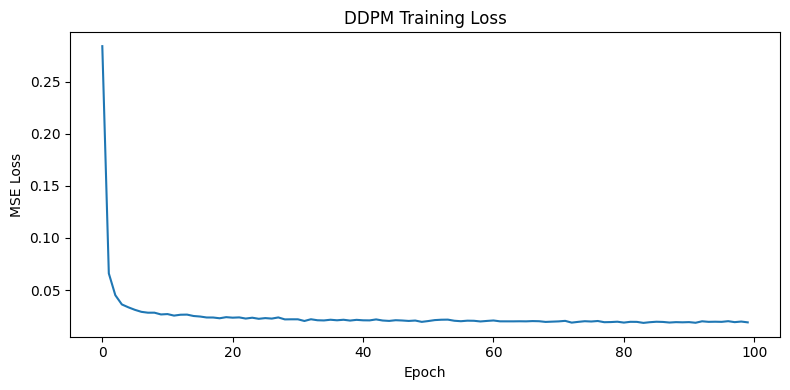

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(losses); plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('DDPM Training Loss'); plt.tight_layout()
plt.savefig('results/ddpm/training_curve.png', dpi=150); plt.show()

# Sampling (Generating Images)
Starting from pure noise x_T ~ N(0,1), then iteratively denoise, steps:
For t = T-1, T-2, ..., 0:
1. Predict noise: ε_pred = model(x_t, t)
2. Remove some noise: x_{t-1} = formula(x_t, ε_pred, t)
3. Add a tiny bit of fresh noise (for all steps except the last)

This is SLOW (1000 forward passes) but it's supposed to produce sharp(er) images (no sharp images in CIFAR10 TT)

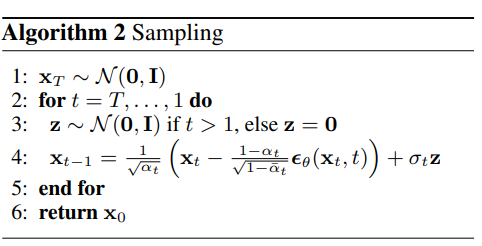

In [46]:

@torch.no_grad() # Freezing the gradients -> inference
def sample(model, n_images=8):
    model.eval() # Putting the model in evaluation mode (disables groupnorm)
    # 0- Start from pure noise
    x = torch.randn(n_images, config.in_channels, 32, 32).to(device)

    for t_val in tqdm(reversed(range(config.timesteps)), total=config.timesteps, desc='Sampling'):
        # Create a tensor filled with the current timestep value for all images in the batch
        t = torch.full((n_images,), t_val, device=device, dtype=torch.long)

        # 1- Predict noise at this step
        noise_pred = model(x, t)

        # Precomputed values for this timestep (for the next steps) from the scheduler
        alpha_t = schedule.alphas[t_val]
        alpha_bar_t = schedule.alphas_cumprod[t_val]
        beta_t = schedule.betas[t_val]
        # 2- Denoise one step: the DDPM reverse formula -> in reversed time steps
        # x_{t-1} = (1/√α_t) * (x_t - (β_t/√(1-ᾱ_t)) * predicted_noise) + σ_t * z
        coef = beta_t / schedule.sqrt_one_minus_alphas_cumprod[t_val]
        x = (1 / torch.sqrt(alpha_t)) * (x - coef * noise_pred)

        # 3- Add noise for all steps except the very last one (t=0)
        # Otherwise: results/ddpm/generated_samples_no_noiseAdded.png
        if t_val > 0:
            noise = torch.randn_like(x)
            sigma = torch.sqrt(beta_t)
            x = x + sigma * noise

    return x.clamp(0, 1) # Otherwise: results/ddpm/generated_samples_no_xClipping.png

## Generate samples

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

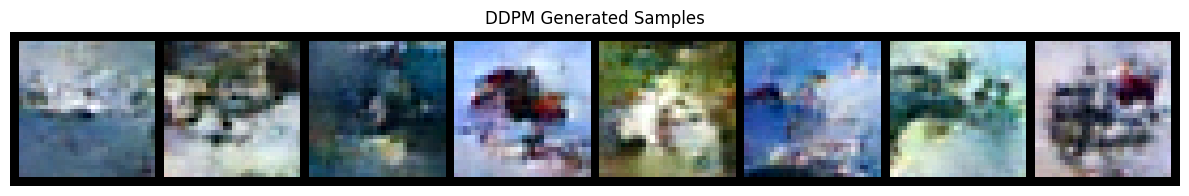

In [47]:
samples = sample(model, n_images=8)

grid = torchvision.utils.make_grid(samples.cpu(), nrow=8, padding=2)
plt.figure(figsize=(12, 3))
plt.imshow(grid.permute(1,2,0)); plt.axis('off')
plt.title('DDPM Generated Samples'); plt.tight_layout()
plt.savefig('results/ddpm/generated_samples_8.png', dpi=150); plt.show()

# Interpolation -> higher quality images!!!